# Wind input against SWAN

`waveray`'s transfer operator can carry stationary wind forcing: the exponential
growth of Komen et al. (1984) integrated along each ray, plus (with `agrow=True`)
the linear seeding of Cavaleri and Malanotte-Rizzoli (1981). Both are *input*
source terms. What the operator cannot carry is whitecapping or quadruplet
interactions — they are nonlinear in the spectral density `E`, so they cannot
live in a linear, frequency-diagonal transfer operator the way refraction and
shoaling can.

Unbalanced input has no ceiling, so waveray adds an **empirical closure**
(`waveray.saturation`): the energy the wind *adds* is capped at a multiple of
the fetch-limited (JONSWAP) spectrum. Two design points matter for reading what
follows:

- The cap applies to the wind **increment**, never to the total spectrum. The
  operator stores a second transfer matrix with the wind term omitted, so the
  increment is exactly recoverable and propagated swell is exempt by
  construction. An earlier version capped the total against a fully developed
  reference and destroyed swell — a 14 s swell under an 8 m/s breeze lost 71 %
  of its height, because the reference rolls off below the wind-sea peak, which
  is exactly where swell lives.
- It is **off by default** (`transform(..., saturation=True)` to enable), because
  it is fitted rather than derived. The cells below show both.

SWAN runs with its full physics throughout, so these are surrogate errors: how
wrong you are using waveray in place of a real SWAN run.

In [1]:
%matplotlib inline
import sys
import tempfile
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")  # repo root (src layout, waveray is installed editable)
sys.path.insert(0, "../tests")  # validation.cases, validation.swan

from validation.cases import plane_beach_case, wind_growth_case, wind_on_swell_case
from validation.swan import swan_image_available

from waveray.bathymetry import LocalGrid
from waveray.operator import build_operator

assert swan_image_available(pull=False), "docker pull delftwaves/swan:latest first"

# SWAN scratch (bathymetry, boundary spectra, PRINT/table output) goes to
# a temp dir, never into the repository.
WORKDIR = Path(tempfile.mkdtemp(prefix="waveray_swan_wind_"))

# Validated palette (dataviz reference instance, light mode) -- matches 02_abrolhos_validation.ipynb
SURFACE = "#fcfcfb"
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
BLUE, AQUA, YELLOW, ORANGE = "#2a78d6", "#1baf7a", "#eda100", "#eb6834"
LAND = "#e4e3dd"

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.size": 10,
        "axes.edgecolor": "#d5d4cf",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "600",
        "axes.titlelocation": "left",
        "axes.titlepad": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "grid.color": "#ecebe6",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
        "lines.solid_capstyle": "round",
    }
)

# SWAN = orange, waveray(+wind) = blue, waveray(no wind) = muted grey-green throughout.
COLOR_SWAN, COLOR_WRAY, COLOR_NOWIND = ORANGE, BLUE, AQUA


def run_both_wind(case, **build_kwargs):
    """Run SWAN and waveray on a wind case; print (not silently drop) any
    growth-clip warning -- it is informative here, not noise."""
    sw = case.run_swan(WORKDIR / case.name)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        wr = case.run_waveray(**build_kwargs)
    for w in caught:
        if issubclass(w.category, UserWarning):
            print(f"[UserWarning] {w.message}")
    return sw, wr

## Fetch-limited growth from a calm sea

`wind_growth_case()`: flat 30 m seabed, **zero boundary energy**, uniform 12 m/s
onshore wind. Everything at the targets is wind sea generated locally as the
fetch increases.

This is the surrogate's hardest case. The *shape* of a wind sea is set by a
balance — input pumps energy in, whitecapping bleeds it off the forward face,
quadruplets move it down toward the peak — and waveray has the input and neither
sink, so nothing stops it growing. Uncapped it over-predicts severalfold; the
closure is what brings it back. Both are plotted.

[UserWarning] wind growth hit the max_growth=100 ceiling on 5.9% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
[UserWarning] wind growth hit the max_growth=100 ceiling on 10.0% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
[UserWarning] wind growth hit the max_growth=100 ceiling on 11.7% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.


findfont: Failed to find font weight 600, now using 700.


[UserWarning] wind growth hit the max_growth=100 ceiling on 5.9% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
[UserWarning] wind growth hit the max_growth=100 ceiling on 10.0% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
[UserWarning] wind growth hit the max_growth=100 ceiling on 11.7% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.


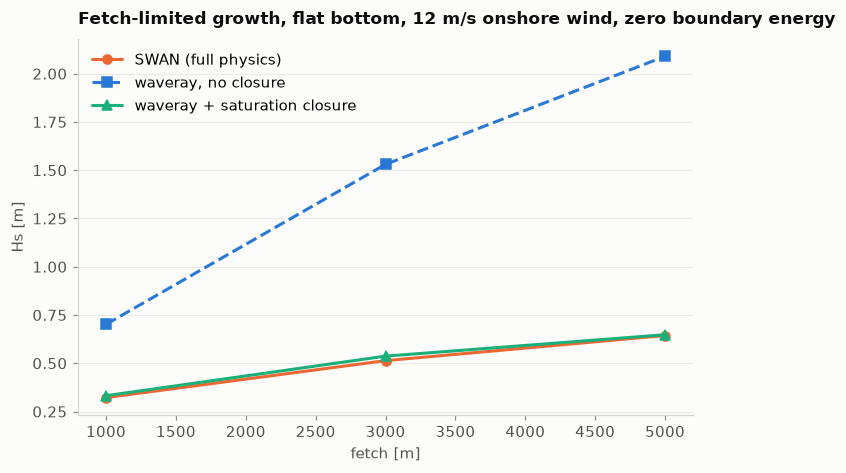

,fetch [m],SWAN Hs [m],waveray capped [m],waveray Hs [m],waveray/SWAN
0,1000.0,0.3223,0.3320,0.7019,2.1777
1,3000.0,0.5136,0.5369,1.5304,2.9795
2,5000.0,0.6437,0.6479,2.0899,3.2465


In [2]:
case_growth = wind_growth_case(name="windsea")
# the closure is opt-in, so both variants are run: uncapped shows the raw
# input-only behaviour, capped shows what the empirical ceiling recovers
sw_growth, wr_growth = run_both_wind(case_growth)
_, wr_growth_cap = run_both_wind(case_growth, transform_kwargs={"saturation": True})

fetch = [tx for tx, _ty in case_growth.targets]

fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.grid(axis="y", zorder=0)
ax.plot(fetch, sw_growth["HSIGN"], "o-", color=COLOR_SWAN, label="SWAN (full physics)", zorder=3)
ax.plot(
    fetch, wr_growth["HSIGN"], "s--", color=COLOR_WRAY,
    label="waveray, no closure", zorder=3,
)
ax.plot(
    fetch, wr_growth_cap["HSIGN"], "^-", color=COLOR_NOWIND,
    label="waveray + saturation closure", zorder=4,
)
ax.set_xlabel("fetch [m]")
ax.set_ylabel("Hs [m]")
ax.set_title("Fetch-limited growth, flat bottom, 12 m/s onshore wind, zero boundary energy")
ax.legend()
fig.tight_layout()
plt.show()

pd.DataFrame(
    {
        "fetch [m]": fetch,
        "SWAN Hs [m]": sw_growth["HSIGN"],
        "waveray capped [m]": wr_growth_cap["HSIGN"],
        "waveray Hs [m]": wr_growth["HSIGN"],
        "waveray/SWAN": wr_growth["HSIGN"] / sw_growth["HSIGN"],
    }
).round(4)

In [3]:
ratio_growth = wr_growth["HSIGN"] / sw_growth["HSIGN"]
ratio_growth_cap = wr_growth_cap["HSIGN"] / sw_growth["HSIGN"]
print(
    f"both models grow with fetch: SWAN {np.all(np.diff(sw_growth['HSIGN']) > 0)}, "
    f"waveray {np.all(np.diff(wr_growth['HSIGN']) > 0)}"
)
print(f"waveray/SWAN, no closure : {np.round(ratio_growth, 3)}")
print(f"waveray/SWAN, with cap   : {np.round(ratio_growth_cap, 3)}")
print(
    f"\nworst error {abs(1 - ratio_growth).max():.0%} without the closure, "
    f"{abs(1 - ratio_growth_cap).max():.0%} with it"
)

both models grow with fetch: SWAN True, waveray True
waveray/SWAN, no closure : [2.178 2.98  3.246]
waveray/SWAN, with cap   : [1.03  1.045 1.007]

worst error 225% without the closure, 5% with it


### Like for like: strip SWAN's sinks too

The factor above mixes two things — whether waveray's *formulation* of the wind input is
right, and what omitting the sinks costs. Running SWAN with quadruplets and whitecapping
off separates them: both models then carry wind input and nothing else, so what remains is
the formulation. (This variant runs on the narrower swell grid, because unbalanced SWAN
collapses to zero if the spectrum reaches ~1 Hz.)

In [4]:
case_lfl = wind_growth_case(name="windsea_lfl", swan_full_physics=False)
# both models carry wind input alone here, so the closure (which stands in
# for the sinks SWAN also has off) must stay out of the way
sw_lfl, wr_lfl = run_both_wind(case_lfl)
ratio_lfl = wr_lfl["HSIGN"] / sw_lfl["HSIGN"]

print(f"SWAN (wind input only) Hs : {np.round(sw_lfl['HSIGN'], 4)}")
print(f"waveray                Hs : {np.round(wr_lfl['HSIGN'], 4)}")
print(f"waveray / SWAN            : {np.round(ratio_lfl, 3)}")
print(
    f"\nlike-for-like disagreement is {abs(1 - ratio_lfl).max():.0%} at worst, "
    f"against {abs(1 - ratio_growth).max():.0%} versus full physics"
)

[UserWarning] wind growth hit the max_growth=100 ceiling on 0.2% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
SWAN (wind input only) Hs : [0.0562 0.1499 0.3434]
waveray                Hs : [0.0429 0.1008 0.2048]
waveray / SWAN            : [0.763 0.672 0.596]

like-for-like disagreement is 40% at worst, against 225% versus full physics


## Wind on swell: the realistic downscale

`wind_on_swell_case()` is the configuration this operator is actually meant for: a plane
beach carrying a JONSWAP swell boundary (as in the idealised notebook) *plus* a 12 m/s
onshore wind blowing over the same short nearshore fetch. SWAN again needs its full physics
to carry the wind, so it is compared against three series:

- **SWAN**, full physics (swell propagation + wind generation + quadruplets + whitecapping);
- **waveray, with wind** -- the operator built with `wind=(12.0, 270.0), agrow=True`;
- **waveray, no wind** -- the same swell-only propagation as the idealised notebook
  (`plane_beach_case(name="ref", dpm=270.0).run_waveray()`), included as a reference for how
  much the wind term alone adds.

waveray has no dissipation to balance the wind input, so it should sit *above* both the
no-wind reference (wind must add energy) and SWAN (which also loses energy to whitecapping)
-- and the gap to SWAN should widen as the fetch available for wind growth grows relatively
larger toward the shallow end.

[UserWarning] wind growth hit the max_growth=100 ceiling on 0.9% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
[UserWarning] wind growth hit the max_growth=100 ceiling on 3.1% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
[UserWarning] wind growth hit the max_growth=100 ceiling on 3.8% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.


[UserWarning] wind growth hit the max_growth=100 ceiling on 0.9% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
[UserWarning] wind growth hit the max_growth=100 ceiling on 3.1% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
[UserWarning] wind growth hit the max_growth=100 ceiling on 3.8% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.


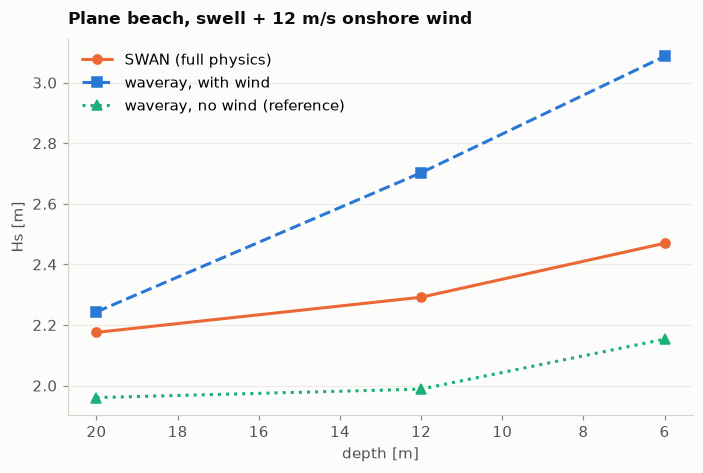

,depth [m],SWAN Hs [m],waveray+wind Hs [m],"waveray+wind, capped [m]",waveray no-wind Hs [m],waveray+wind / SWAN
0,20.0,2.1757,2.2434,2.0746,1.9604,1.0311
1,12.0,2.2917,2.7025,2.3115,1.9883,1.1793
2,6.0,2.4698,3.0868,2.5934,2.1532,1.2498


In [5]:
case_windswell = wind_on_swell_case(name="windswell")
sw_windswell, wr_windswell = run_both_wind(case_windswell)
_, wr_windswell_cap = run_both_wind(
    case_windswell, transform_kwargs={"saturation": True}
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # no wind on the reference case -> nothing to catch
    wr_nowind = plane_beach_case(name="ref", dpm=270.0).run_waveray()

depths_windswell = [
    case_windswell.grid.sample_depth(np.array([tx]), np.array([ty]))[0]
    for tx, ty in case_windswell.targets
]

fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.grid(axis="y", zorder=0)
ax.plot(
    depths_windswell,
    sw_windswell["HSIGN"],
    "o-",
    color=COLOR_SWAN,
    label="SWAN (full physics)",
    zorder=3,
)
ax.plot(
    depths_windswell,
    wr_windswell["HSIGN"],
    "s--",
    color=COLOR_WRAY,
    label="waveray, with wind",
    zorder=3,
)
ax.plot(
    depths_windswell,
    wr_nowind["HSIGN"],
    "^:",
    color=COLOR_NOWIND,
    label="waveray, no wind (reference)",
    zorder=3,
)
ax.invert_xaxis()
ax.set_xlabel("depth [m]")
ax.set_ylabel("Hs [m]")
ax.set_title("Plane beach, swell + 12 m/s onshore wind")
ax.legend()
fig.tight_layout()
plt.show()

pd.DataFrame(
    {
        "depth [m]": depths_windswell,
        "SWAN Hs [m]": sw_windswell["HSIGN"],
        "waveray+wind Hs [m]": wr_windswell["HSIGN"],
        "waveray+wind, capped [m]": wr_windswell_cap["HSIGN"],
        "waveray no-wind Hs [m]": wr_nowind["HSIGN"],
        "waveray+wind / SWAN": wr_windswell["HSIGN"] / sw_windswell["HSIGN"],
    }
).round(4)

In [6]:
ratio_windswell = wr_windswell["HSIGN"] / sw_windswell["HSIGN"]
ratio_windswell_cap = wr_windswell_cap["HSIGN"] / sw_windswell["HSIGN"]
adds_energy = np.all(wr_windswell_cap["HSIGN"] > wr_nowind["HSIGN"])
print(f"wind adds energy over the no-wind reference at every target: {adds_energy}")
print(f"waveray/SWAN, no closure : {np.round(ratio_windswell, 3)}")
print(f"waveray/SWAN, with cap   : {np.round(ratio_windswell_cap, 3)}")
print(
    f"\nworst error {abs(1 - ratio_windswell).max():.0%} without the closure, "
    f"{abs(1 - ratio_windswell_cap).max():.0%} with it"
)

wind adds energy over the no-wind reference at every target: True
waveray/SWAN, no closure : [1.031 1.179 1.25 ]
waveray/SWAN, with cap   : [0.954 1.009 1.05 ]

worst error 25% without the closure, 5% with it


## The runaway demonstration: why `max_growth` exists

The Komen growth term integrates a rate `B` along the ray path; the net gain is
`exp(integral B ds)`. In deep water the group velocity `cg ~ g / (4*pi*f)` gets *smaller*
as frequency increases, so a ray at high frequency spends longer covering the same fetch --
its growth exponent accumulates for longer. SWAN keeps this in check with quadruplets
(downshifting energy away) and whitecapping (dissipating it); a linear operator has neither,
so wind input on its own really is unbounded on a long enough high-frequency fetch -- this
is not a numerical artefact, it is what "input only" structurally means.

`build_operator`'s `max_growth` parameter (default 100 -- a hundredfold energy gain per ray)
floors the growth exponent so the operator stays finite, and raises a `UserWarning` reporting
what fraction of rays hit the ceiling. The cell below builds the same flat-bottom wind case
directly with `waveray.operator.build_operator`, once with `max_growth=None` and once with
the default `max_growth=100.0`, over a frequency range (0.05-1.0 Hz) wide enough to include
poorly-resolved high frequencies, and plots the resulting wind-generated spectrum `E(f)` on
a log axis.

In [7]:
length = 15_000.0
halfwidth = 4_000.0
nx, ny = 61, 41
x = np.linspace(0.0, length, nx)
y = np.linspace(-halfwidth, halfwidth, ny)
depth = np.full((ny, nx), 30.0)
grid = LocalGrid(x=x, y=y, depth=depth)

freqs = np.linspace(0.05, 1.0, 25)
dirs = np.arange(0.0, 360.0, 10.0)
dd = float(dirs[1] - dirs[0])
target_xy = (length - 500.0, 0.0)
boundary_xy = np.array([[0.0, -1_000.0], [0.0, 1_000.0]])

ops = {}
for max_growth in (None, 100.0):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        ops[max_growth] = build_operator(
            grid,
            target_xy,
            boundary_xy,
            freqs,
            dirs,
            cf_jonswap=None,
            wind=(15.0, 270.0),
            agrow=True,
            max_growth=max_growth,
        )
    label = (
        "unbounded (max_growth=None)"
        if max_growth is None
        else f"capped (max_growth={max_growth:g})"
    )
    if caught:
        for w in caught:
            print(f"[{label}] [UserWarning] {w.message}")
    else:
        print(f"[{label}] no warning raised")

e_unbounded = ops[None].E0.sum(axis=1) * dd
e_capped = ops[100.0].E0.sum(axis=1) * dd
print(
    f"\nE(f) at the highest frequency ({freqs[-1]:.2f} Hz): "
    f"unbounded = {e_unbounded[-1]:.3e} m^2/Hz, capped = {e_capped[-1]:.3e} m^2/Hz"
)

[unbounded (max_growth=None)] no warning raised


[capped (max_growth=100)] [UserWarning] wind growth hit the max_growth=100 ceiling on 27.5% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.

E(f) at the highest frequency (1.00 Hz): unbounded = 3.499e+151 m^2/Hz, capped = 7.636e+00 m^2/Hz


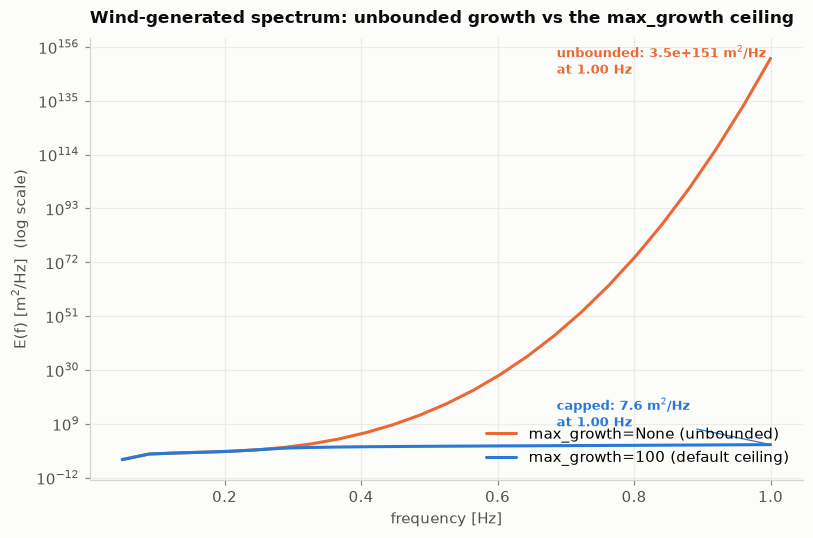

unbounded growth spans 156 orders of magnitude across the resolved frequency range; the capped run spans 5.8.


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5.0))
ax.grid(zorder=0, which="both")
ax.plot(freqs, e_unbounded, color=COLOR_SWAN, label="max_growth=None (unbounded)", zorder=3)
ax.plot(freqs, e_capped, color=COLOR_WRAY, label="max_growth=100 (default ceiling)", zorder=3)
ax.set_yscale("log")
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("E(f) [m$^2$/Hz]  (log scale)")
ax.set_title("Wind-generated spectrum: unbounded growth vs the max_growth ceiling")
ax.annotate(
    f"unbounded: {e_unbounded[-1]:.1e} m$^2$/Hz\nat {freqs[-1]:.2f} Hz",
    xy=(freqs[-1], e_unbounded[-1]),
    xytext=(-140, -10),
    textcoords="offset points",
    color=COLOR_SWAN,
    fontsize=8.5,
    fontweight="600",
    arrowprops=dict(arrowstyle="-", color=COLOR_SWAN, lw=0.8),
)
ax.annotate(
    f"capped: {e_capped[-1]:.1f} m$^2$/Hz\nat {freqs[-1]:.2f} Hz",
    xy=(freqs[-1], e_capped[-1]),
    xytext=(-140, 12),
    textcoords="offset points",
    color=COLOR_WRAY,
    fontsize=8.5,
    fontweight="600",
    arrowprops=dict(arrowstyle="-", color=COLOR_WRAY, lw=0.8),
)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

print(
    f"unbounded growth spans {np.log10(e_unbounded.max() / e_unbounded.min()):.0f} "
    f"orders of magnitude across the resolved frequency range; "
    f"the capped run spans {np.log10(e_capped.max() / e_capped.min()):.1f}."
)

## Conclusions

Wind input in waveray is an *input-only* term: no quadruplets to downshift
energy, no whitecapping to dissipate it, because neither can be written as a
linear, frequency-diagonal operator. The saturation closure supplies the outcome
of that balance empirically rather than modelling it.

- **Generating a wind sea** is the hardest ask. Uncapped the operator
  over-predicts severalfold and grows worse with wind speed; with the closure it
  lands far closer (see the ratios printed above). The residual is not a badly
  fitted constant: at low wind and short fetch the uncapped operator is already
  *below* SWAN, and a cap can only subtract — so no value of `k` reaches parity
  there. The lever for that regime is the seeding and the missing downshift, not
  the ceiling.
- **Wind added to an existing swell over a short nearshore fetch** is the
  intended use, and the departure from SWAN is bounded and grows gradually with
  fetch.
- **Left unbounded, wind input is structurally unstable — in both models.** SWAN
  with its sinks off grows a 2 m swell to tens of metres over the same fetch, and
  collapses to zero outright if the spectrum reaches ~1 Hz. That is why
  `max_growth` exists and defaults on.

**When to switch wind on:** short nearshore fetches where the boundary swell
dominates the target energy. Treat it as a correction to swell that is already
there, never as a way to grow a sea. Enable the closure explicitly, and check
`wind_saturation_scale_min` to see whether it engaged.